# Data Analysis: Global air temperature observations

In this notebook, we analyse the temperature observations.
We perform EDA to understand the attributes and how they influence temperature. Also we visualise the station locations across the globe and their density.

Data: 

observations_qc.csv

land_fraction_data.csv

roughness_data.csv

We use additional predictors along with the intially provided covariates to potentially improve learning process of our models.

## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm
from timezonefinder import TimezoneFinder

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Libraries for Neural Networks
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, models
import datetime
from tensorflow.keras.callbacks import TensorBoard
import keras
print(tf.__version__)

import keras_tuner
import math

2.19.0


## Loading Observations and additional predictors

In [6]:
obs = pd.read_csv('./datasets/observations_qc.csv', compression="gzip", parse_dates=["time"])
land_frac_data = pd.read_csv('./datasets/land_fraction_data.csv', compression="gzip")
roughness_data = pd.read_csv('./datasets/roughness_data.csv', compression="gzip")

obs = obs.merge(land_frac_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])
obs = obs.merge(roughness_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])

print(obs.shape)
print(obs.columns)
print((obs['ob_value']-273.15).min())
print((obs['ob_value']-273.15).max())

(9232630, 9)
Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness'],
      dtype='object')
-79.64999999999998
58.25


## Data Transformations

In [8]:
# Transforming date to a cyclic pattern in a 365 day cycle
obs['day_of_year'] = obs['time'].dt.dayofyear
obs['hour'] = pd.to_datetime(obs['time']).dt.hour

#obs['sin_day'] = np.sin(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)
#obs['cos_day'] = np.cos(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)

obs['sin_day'] = np.sin(2 * np.pi * obs['day_of_year'] / 365).round(5)
obs['cos_day'] = np.cos(2 * np.pi * obs['day_of_year'] / 365).round(5)

# Transforming time to a cyclic pattern - 24 hour cycle by calculating the solar time at positions
obs['sin_hour'] = np.sin(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)
obs['cos_hour'] = np.cos(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)


In [9]:
# Transforming latitude, longitude to [-1,1] range
obs['lat'] = (obs['latitude']/90.0).round(5)
obs['sin_long'] = np.sin(np.radians(obs['longitude'])).round(5)
obs['cos_long'] = np.cos(np.radians(obs['longitude'])).round(5)

obs['temp_celsius'] = obs['ob_value'] - 273.0

In [10]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celsius
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,2,0.52342,0.85208,-0.76034,0.64953,-0.93333,-0.98324,0.18234,-18.0
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,4,0.52342,0.85208,-0.33371,0.94268,-0.93333,-0.98324,0.18234,-18.2
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,6,0.52342,0.85208,0.18234,0.98324,-0.93333,-0.98324,0.18234,-17.7
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,7,0.52342,0.85208,0.43061,0.90254,-0.93333,-0.98324,0.18234,-17.5
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,8,0.52342,0.85208,0.64953,0.76034,-0.93333,-0.98324,0.18234,-17.7
5,254.5,2025-02-01 09:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,9,0.52342,0.85208,0.82419,0.56632,-0.93333,-0.98324,0.18234,-18.5
6,254.5,2025-02-01 10:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,10,0.52342,0.85208,0.94268,0.33371,-0.93333,-0.98324,0.18234,-18.5
7,254.1,2025-02-01 12:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,12,0.52342,0.85208,0.98324,-0.18234,-0.93333,-0.98324,0.18234,-18.9
8,253.6,2025-02-01 13:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,13,0.52342,0.85208,0.90254,-0.43061,-0.93333,-0.98324,0.18234,-19.4
9,255.4,2025-02-01 19:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,19,0.52342,0.85208,-0.43061,-0.90254,-0.93333,-0.98324,0.18234,-17.6


## EDA on new predictors

In [12]:
land_frac_data

,wmo_id,latitude,longitude,altitude,land_fraction
0,89079,-84.000,-79.494,1285.0,1.000000
1,89087,-85.200,-87.883,1634.0,1.000000
2,89577,-80.368,77.374,4084.0,1.000000
3,89013,-82.767,-13.050,1968.0,1.000000
4,89667,-77.952,166.500,8.0,0.000000
...,...,...,...,...,...
7870,4312,81.603,-16.663,34.0,1.000000
7871,4313,80.649,-13.712,8.0,0.000000
7872,20046,80.626,58.059,21.0,0.033826
7873,71355,82.494,-62.352,60.0,0.940505


In [13]:
roughness_data

,wmo_id,latitude,longitude,altitude,roughness
0,89079,-84.000,-79.494,1285.0,0.000615
1,89087,-85.200,-87.883,1634.0,0.002648
2,89577,-80.368,77.374,4084.0,0.000549
3,89013,-82.767,-13.050,1968.0,0.000573
4,89667,-77.952,166.500,8.0,0.001549
...,...,...,...,...,...
7870,4312,81.603,-16.663,34.0,0.030000
7871,4313,80.649,-13.712,8.0,0.030000
7872,20046,80.626,58.059,21.0,0.030000
7873,71355,82.494,-62.352,60.0,0.059860


In [14]:
print(land_frac_data['land_fraction'].min())
print(land_frac_data['land_fraction'].max())
print(roughness_data['roughness'].min())
print(roughness_data['roughness'].max())

0.0
1.0
0.00049972534
51.83767


In [15]:
land_frac_data.isna().sum()

wmo_id           0
latitude         0
longitude        0
altitude         0
land_fraction    0
dtype: int64

In [16]:
print(land_frac_data['wmo_id'].unique().shape)
print(roughness_data['wmo_id'].unique().shape)

(7856,)
(7856,)


In [17]:
# Counting unique locations
unique_landfrac = land_frac_data.drop_duplicates(subset=['latitude', 'longitude','wmo_id','altitude'])
unique_landfrac

,wmo_id,latitude,longitude,altitude,land_fraction
0,89079,-84.000,-79.494,1285.0,1.000000
1,89087,-85.200,-87.883,1634.0,1.000000
2,89577,-80.368,77.374,4084.0,1.000000
3,89013,-82.767,-13.050,1968.0,1.000000
4,89667,-77.952,166.500,8.0,0.000000
...,...,...,...,...,...
7870,4312,81.603,-16.663,34.0,1.000000
7871,4313,80.649,-13.712,8.0,0.000000
7872,20046,80.626,58.059,21.0,0.033826
7873,71355,82.494,-62.352,60.0,0.940505


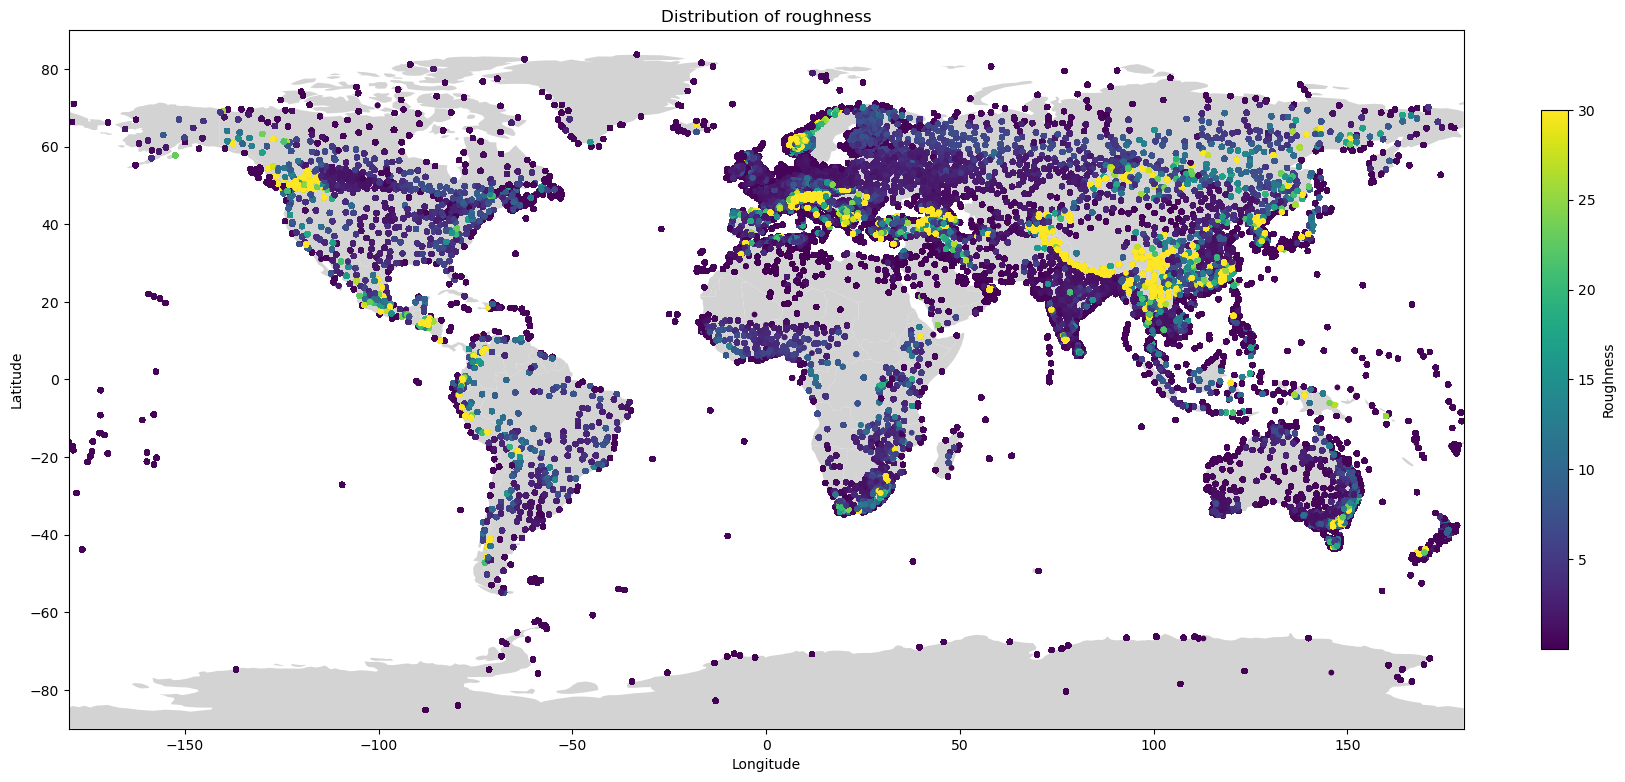

In [18]:

# From GeoPandas, our world map data
worldmap = gpd.read_file('./ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

# Creating axes and plotting world map
fig, ax = plt.subplots(figsize=(20, 14))
worldmap.plot(color="lightgrey", ax=ax, legend=False)

# Plotting our Impact Energy data with a color map
x = obs['longitude']
y = obs['latitude']
z = obs['roughness']
plt.scatter(x, y, s=10, c=10*z, vmin=obs['roughness'].min(), vmax=30, cmap='viridis')

plt.colorbar(label='Roughness', fraction=0.05, shrink = 0.5)

# Creating axis limits and title
plt.xlim([-180, 180])
plt.ylim([-90, 90])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title('Distribution of roughness')
plt.show()


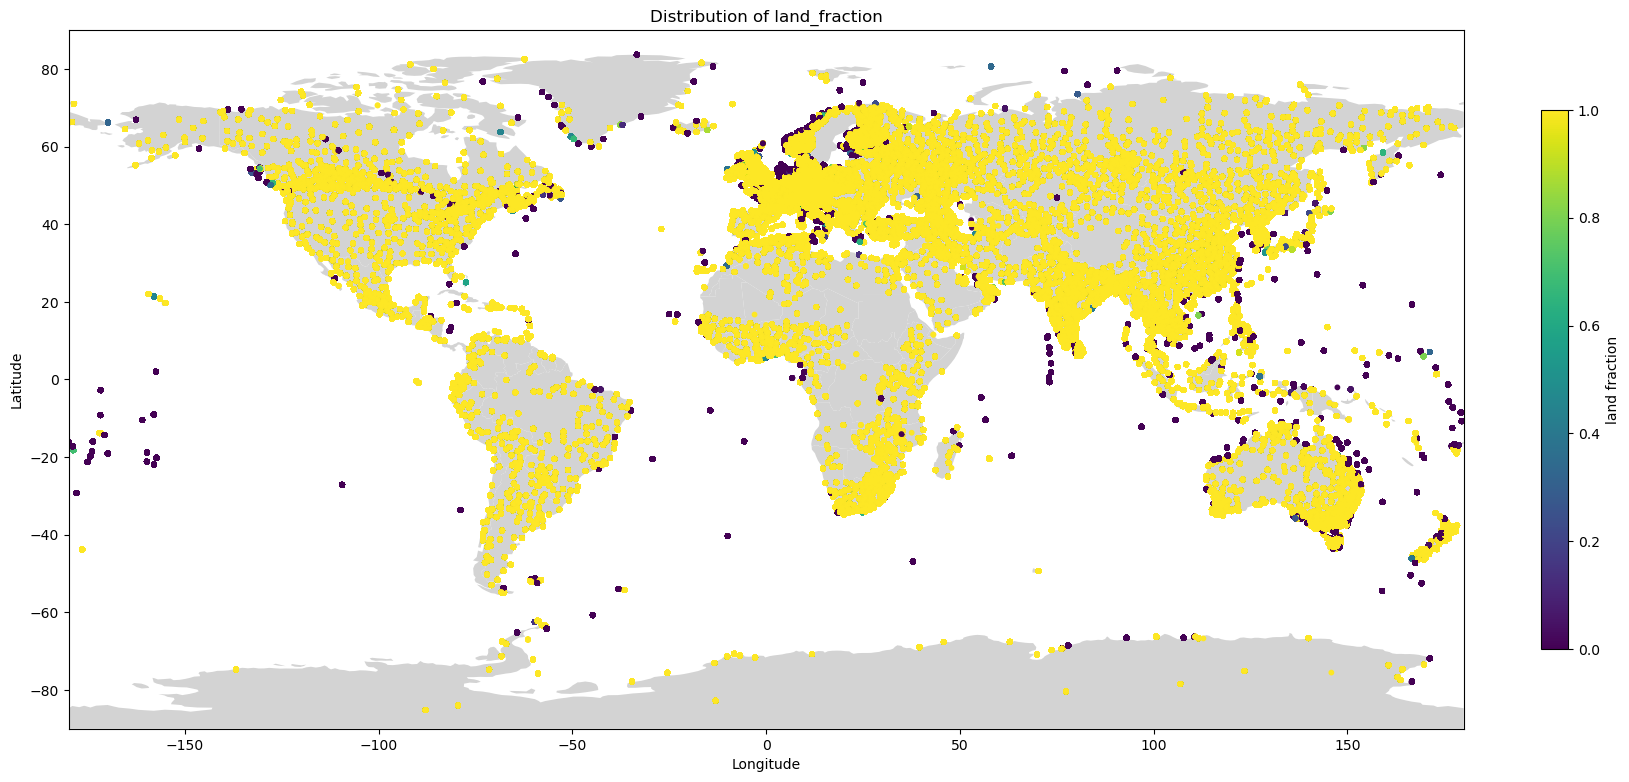

In [19]:

# From GeoPandas, our world map data
worldmap = gpd.read_file('./ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

# Creating axes and plotting world map
fig, ax = plt.subplots(figsize=(20, 14))
worldmap.plot(color="lightgrey", ax=ax, legend=False)

# Plotting our Impact Energy data with a color map
x = obs['longitude']
y = obs['latitude']
z = obs['land_fraction']
plt.scatter(x, y, s=10, c=10*z, vmin=obs['land_fraction'].min(), vmax=obs['land_fraction'].max(), cmap='viridis')

plt.colorbar(label='land fraction', fraction=0.05, shrink = 0.5)

# Creating axis limits and title
plt.xlim([-180, 180])
plt.ylim([-90, 90])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title('Distribution of land_fraction')
plt.show()


## Preliminary Analysis, EDA and Regression Models

### EDA

In [22]:
# Check missing values
obs.isna().sum()

ob_value         0
time             0
wmo_id           0
diagnostic       0
latitude         0
longitude        0
altitude         0
land_fraction    0
roughness        0
day_of_year      0
hour             0
sin_day          0
cos_day          0
sin_hour         0
cos_hour         0
lat              0
sin_long         0
cos_long         0
temp_celsius     0
dtype: int64

In [23]:
unique_vals = obs['wmo_id'].unique()
unique_vals.shape

(7856,)

In [24]:
# Essentially 'wmo_id' are weather station Ids
location_data = obs['wmo_id'].value_counts().reset_index()
location_data.columns = ['wmo_id', 'obs_count']
location_data.head(10)
location_data.iloc[3]

wmo_id       3377
obs_count    2652
Name: 3, dtype: int64

In [25]:
# Counting unique locations
unique_locations = obs.drop_duplicates(subset=['latitude', 'longitude','wmo_id','altitude'])
#print("Number of unique locations:", len(unique_locations))
unique_locations

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celsius
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.000,-79.494,1285.0,1.000000,0.000615,32,2,0.52342,0.85208,-0.76034,0.64953,-0.93333,-0.98324,0.18234,-18.0
1198,254.9,2025-02-01 00:00:00+00:00,89087,temperature_at_screen_level,-85.200,-87.883,1634.0,1.000000,0.002648,32,0,0.52342,0.85208,-0.99932,0.03694,-0.94667,-0.99932,0.03694,-18.1
3691,234.5,2025-02-01 00:00:00+00:00,89577,temperature_at_screen_level,-80.368,77.374,4084.0,1.000000,0.000549,32,0,0.52342,0.85208,0.97582,0.21859,-0.89298,0.97582,0.21859,-38.5
3744,250.3,2025-02-03 16:00:00+00:00,89013,temperature_at_screen_level,-82.767,-13.050,1968.0,1.000000,0.000573,34,16,0.55244,0.83356,-0.73076,-0.68264,-0.91963,-0.22580,0.97417,-22.7
5941,276.4,2025-05-08 23:00:00+00:00,89667,temperature_at_screen_level,-77.952,166.500,8.0,0.000000,0.001549,128,23,0.80648,-0.59126,0.47716,-0.87882,-0.86613,0.23345,-0.97237,3.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9227104,247.7,2025-02-01 00:00:00+00:00,4312,temperature_at_screen_level,81.603,-16.663,34.0,1.000000,0.030000,32,0,0.52342,0.85208,-0.28674,0.95801,0.90670,-0.28674,0.95801,-25.3
9227110,247.0,2025-02-01 00:00:00+00:00,4313,temperature_at_screen_level,80.649,-13.712,8.0,0.000000,0.030000,32,0,0.52342,0.85208,-0.23704,0.97150,0.89610,-0.23704,0.97150,-26.0
9227111,268.8,2025-02-01 00:00:00+00:00,20046,temperature_at_screen_level,80.626,58.059,21.0,0.033826,0.030000,32,0,0.52342,0.85208,0.84859,0.52905,0.89584,0.84859,0.52905,-4.2
9227113,244.6,2025-02-01 00:00:00+00:00,71355,temperature_at_screen_level,82.494,-62.352,60.0,0.940505,0.059860,32,0,0.52342,0.85208,-0.88582,0.46404,0.91660,-0.88582,0.46404,-28.4


### Grouping observations by latitude and longitude to obtain unique locations. Rest of the columns are aggregated

In [27]:
grouped_obs = obs.groupby(['latitude', 'longitude'], as_index=False).agg({
    'ob_value': 'mean',
    'temp_celsius': 'mean',
    'wmo_id': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'sin_day': 'mean',
    'cos_day': 'mean',
    'sin_hour': 'mean',
    'cos_hour': 'mean',
    'day_of_year': 'mean',
    'altitude': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'hour': 'mean'
})

#grouped_obs.drop_duplicates(subset=['latitude', 'longitude'])
grouped_obs = grouped_obs.round(4)

In [28]:
grouped_obs

,latitude,longitude,ob_value,temp_celsius,wmo_id,sin_day,cos_day,sin_hour,cos_hour,day_of_year,altitude,hour
0,-85.200,-87.883,240.1437,-32.8563,89087,0.8675,0.0486,0.0023,-0.0001,87.9615,1634.0,11.5126
1,-84.000,-79.494,241.7934,-31.2066,89079,0.8547,0.0924,0.1381,0.3251,85.0785,1285.0,8.8932
2,-82.767,-13.050,234.3815,-38.6185,89013,0.8881,0.0570,-0.3272,0.1093,87.5166,1968.0,13.0237
3,-80.368,77.374,217.9582,-55.0418,89577,0.8459,0.0696,0.0044,-0.0194,86.3575,4084.0,11.3291
4,-78.464,106.866,214.4209,-58.5791,89606,0.8579,0.0783,-0.0007,-0.0022,85.9592,3488.0,8.9932
...,...,...,...,...,...,...,...,...,...,...,...,...
7861,80.649,-13.712,256.3121,-16.6879,4313,0.8776,-0.0190,0.0106,-0.0188,92.0532,8.0,9.9484
7862,81.161,-91.816,250.3705,-22.6295,71872,0.8567,0.0759,0.0023,0.0001,86.0847,70.0,9.0069
7863,81.603,-16.663,252.4295,-20.5705,4312,0.8604,0.1139,0.0089,-0.0086,83.7003,34.0,11.4652
7864,82.494,-62.352,250.5059,-22.4941,71355,0.8571,0.0801,-0.0010,0.0031,85.8371,60.0,8.9729


In [29]:
grouped_obs_wmo = grouped_obs['wmo_id'].value_counts().reset_index()
#Some wmo_ids have same lat,long.
grouped_obs_wmo.head(20)

,wmo_id,count
0,7120,2
1,7110,2
2,61052,2
3,7753,2
4,78583,2
5,60445,2
6,7037,2
7,84377,2
8,7040,2
9,7749,2


The lat, long vary slightly for the same wmo_id. Maybe the difference is insignificant? Wmo_id could be considered to have unique lat,long.

In [31]:
grouped_obs[grouped_obs['wmo_id'] == 60445]

,latitude,longitude,ob_value,temp_celsius,wmo_id,sin_day,cos_day,sin_hour,cos_hour,day_of_year,altitude,hour
3489,36.167,5.317,279.9561,6.9561,60445,0.6477,0.7557,0.0160,-0.0043,41.1622,1009.0,10.2973
3490,36.175,5.328,285.2993,12.2993,60445,0.9155,0.0383,-0.0033,0.0040,89.0515,1009.0,10.1835


### Plotting observation counts for each location (wmo_id)

wmo_id
3769     2652
99189    2652
3301     2652
3377     2652
3379     2652
         ... 
38367       1
38755       1
67260       1
61707       1
67157       1
Name: count, Length: 7856, dtype: int64

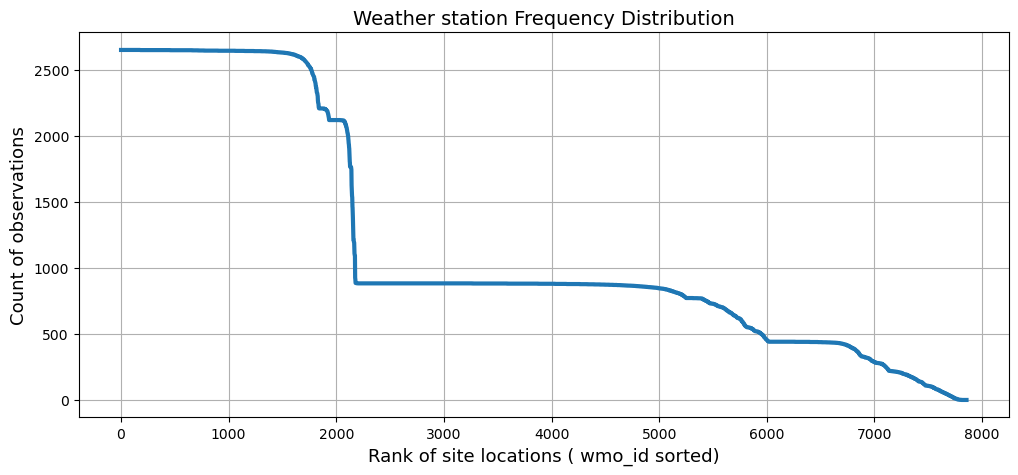

In [33]:
#Plotting observation counts for each location (wmo_id)

counts = obs['wmo_id'].value_counts()
plt.figure(figsize=(12, 5))
plt.plot(counts.values, linewidth=3)
#plt.yscale('log')  # 
plt.title("Weather station Frequency Distribution", fontsize=14)
plt.xlabel("Rank of site locations ( wmo_id sorted)", fontsize=13)
plt.ylabel("Count of observations", fontsize=13)
plt.grid(True)
counts.values.shape
counts

Some locations have more than 2500 observations. Probably ~1/3 of observation sites.

In [35]:
cts = obs['wmo_id'].value_counts().reset_index()
cts[cts['count']==2652].shape

(178, 2)

In [36]:
# Previously, the extreme temperatures were unrealistic. It has been fixed.
print(obs['temp_celsius'].min())
print(obs['temp_celsius'].max())

-79.5
58.39999999999998


### Temperature variation at all locations

The below plot doesn't seem very useful. However we can notice that the temperature has huge variations at certain locations.

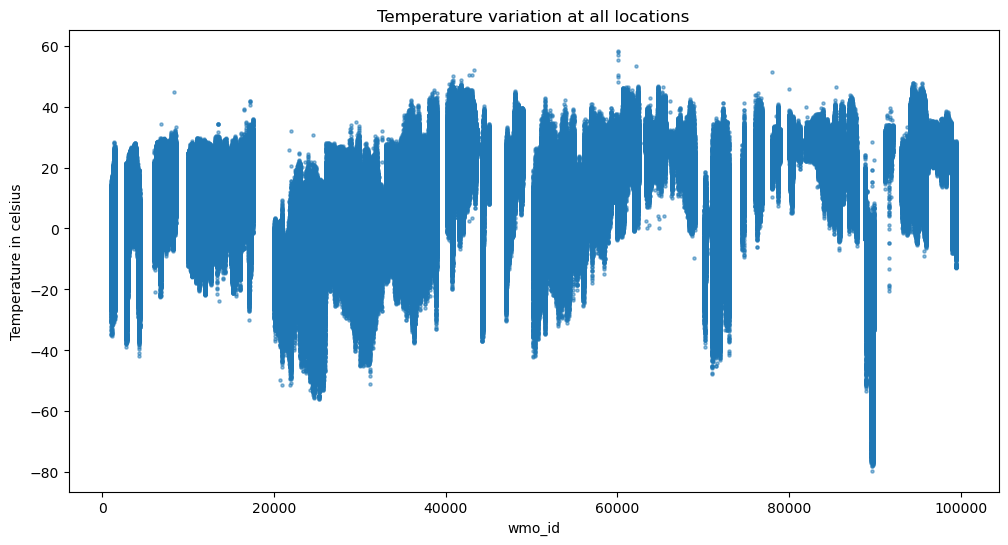

In [39]:
plt.figure(figsize=(12,6))
#plt.scatter(obs[obs['wmo_id'] < 4000]['wmo_id'], obs[obs['wmo_id'] < 4000]['temp_celsius'], s=5, alpha=0.5)
plt.scatter(obs['wmo_id'], obs['temp_celsius'], s=5, alpha=0.5)
plt.title('Temperature variation at all locations')
plt.xlabel('wmo_id')
plt.ylabel('Temperature in celsius')
plt.show()

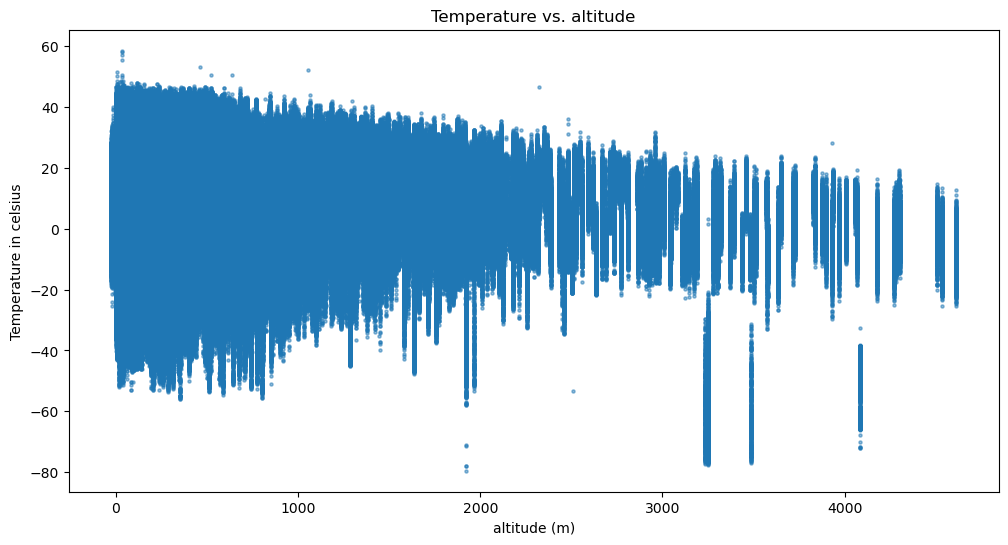

In [40]:
plt.figure(figsize=(12,6))
plt.scatter(obs['altitude'], obs['temp_celsius'], s=5, alpha=0.5)

plt.title('Temperature vs. altitude')
plt.xlabel('altitude (m)')
plt.ylabel('Temperature in celsius')
plt.show()

### Temperature variation over the period at four locations:

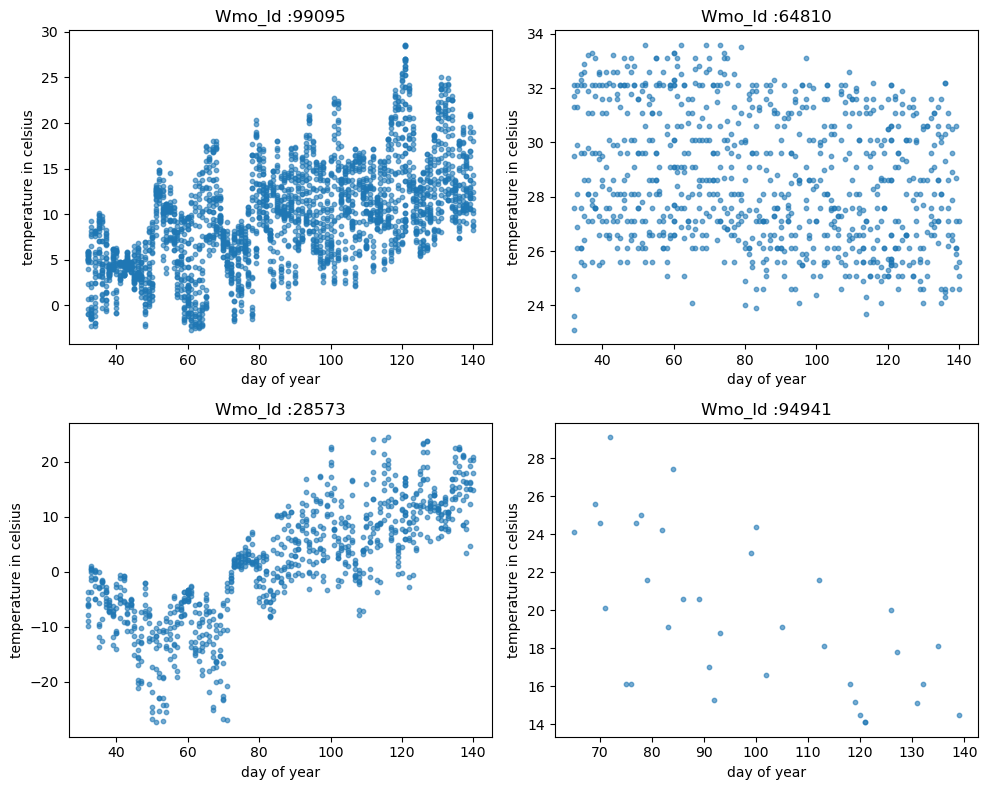

In [42]:
#Plotting the temperature variation for a site
#wmoids = [99095, 7579, 15420, 7630]
#wmoids = [99095, 64810, 28573, 94899]
wmoids = [99095, 64810, 28573, 94941]

plot_data = obs[obs['wmo_id'].isin(wmoids)][['wmo_id','day_of_year', 'temp_celsius']]

plt.figure(figsize=(10,8))
i=0
for _id in wmoids:
    plt.subplot(2,2,i+1)
    subset = plot_data[plot_data['wmo_id'] == _id]
    plt.scatter(subset['day_of_year'], subset['temp_celsius'], alpha = 0.6, s=10)
    plt.title('Wmo_Id :'+ str(_id))
    plt.xlabel('day of year')
    plt.ylabel('temperature in celsius')
    i+=1

plt.tight_layout()
plt.show()

#maybe fit a NW smoothing curve? NW

In [43]:
plotted_locs = grouped_obs[grouped_obs['wmo_id'].isin(wmoids)][['wmo_id','latitude','longitude']]
plotted_locs

,wmo_id,latitude,longitude
320,94941,-35.723,150.187
1623,64810,3.750,8.767
5964,99095,51.482,-0.294
6750,28573,56.100,69.433


In [44]:
## Identifying the locations
plotted_locs['location'] = ['Catalina, Australia', 'Malabo, Equatorial Guinea', 'Richmond, London', 'Ishim, Tyumen Oblast, Russia']
plotted_locs

,wmo_id,latitude,longitude,location
320,94941,-35.723,150.187,"Catalina, Australia"
1623,64810,3.750,8.767,"Malabo, Equatorial Guinea"
5964,99095,51.482,-0.294,"Richmond, London"
6750,28573,56.100,69.433,"Ishim, Tyumen Oblast, Russia"


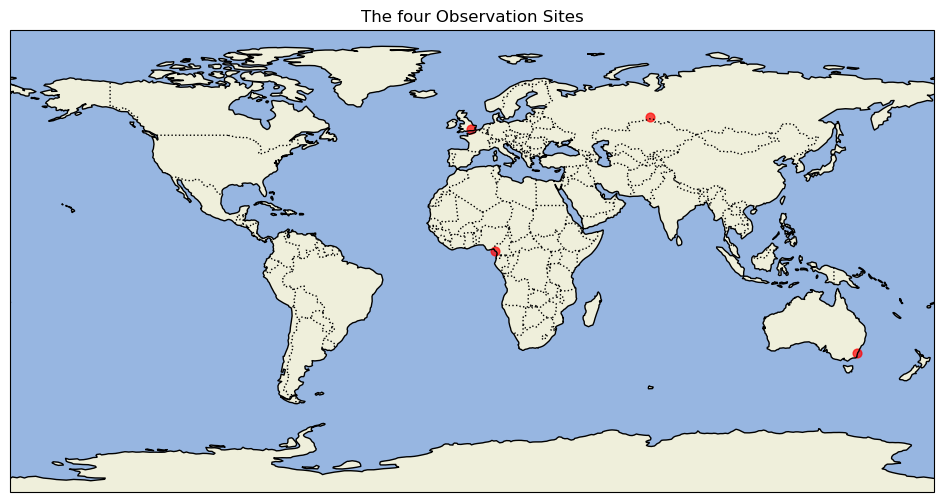

In [45]:
#Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-25, 40, 34, 72], crs=ccrs.PlateCarree())
#Add features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

#Plot points
ax.scatter(plotted_locs['longitude'], plotted_locs['latitude'], color='red', s=40, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("The four Observation Sites")
plt.show()

### EDA on a subset of the dataset: Europe observation sites

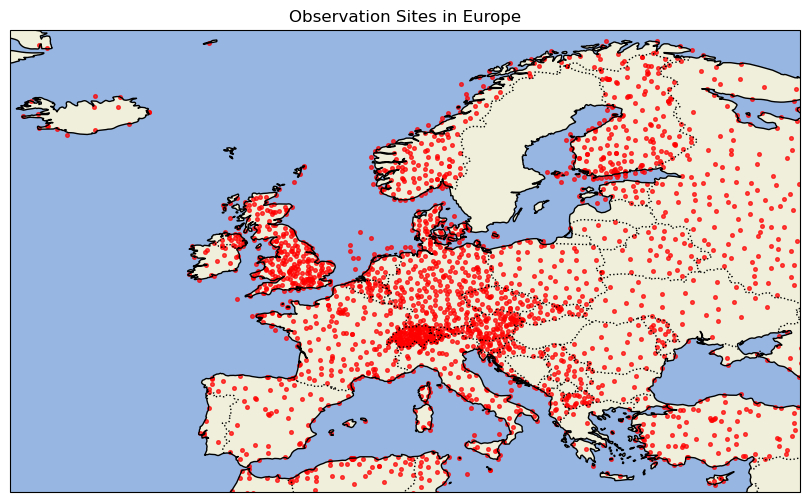

In [47]:

# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-25, 40, 34, 72], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(unique_locations['longitude'], unique_locations['latitude'], color='red', s=7, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Observation Sites in Europe")
plt.show()


Switzerland has a high density of stations in the alpine region.

In [49]:
obs_eu = obs[(obs['latitude'] > 34.0) & (obs['latitude'] < 72.0)  & (obs['longitude'] > -25.0) & (obs['longitude'] < 40.0)]
obs_eu.shape[0]

4546715

In [50]:
print(f'subset : {obs_eu.shape[0]/obs.shape[0]*100 : .2f}')

subset :  49.25


~50% of the observations are from Europe

In [52]:
obs_eu_locs = obs_eu.drop_duplicates(subset=['wmo_id'])

wmo_id
99432    2652
3882     2652
10037    2652
15460    2652
15360    2652
         ... 
11307       7
2942        2
12146       2
99463       2
16564       1
Name: count, Length: 2276, dtype: int64

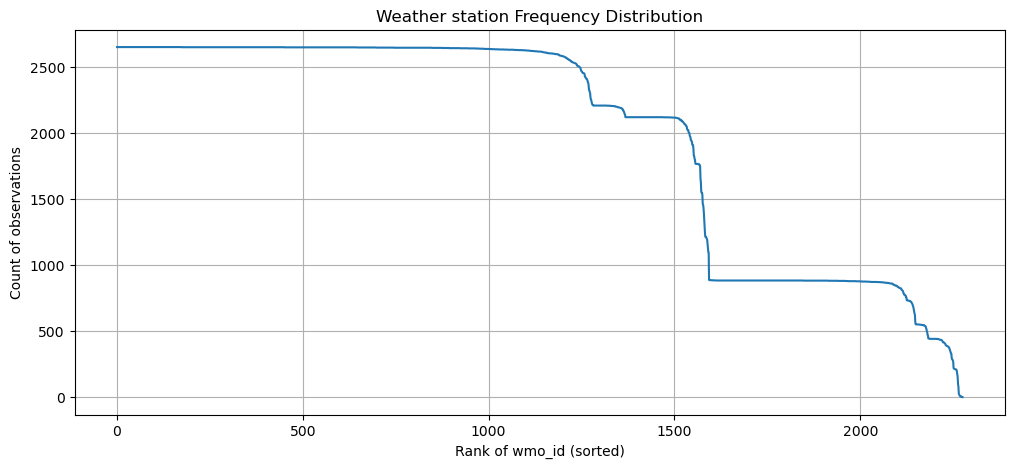

In [53]:
#Plotting observation counts for each location (wmo_id)

counts = obs_eu['wmo_id'].value_counts()
plt.figure(figsize=(12, 5))
plt.plot(counts.values)
#plt.yscale('log')  # 
plt.title("Weather station Frequency Distribution")
plt.xlabel("Rank of wmo_id (sorted)")
plt.ylabel("Count of observations")
plt.grid(True)
counts.values.shape
counts

### Linear Regression Model

In [55]:
x = np.array(obs[obs['altitude']>2000.0]['altitude']).reshape(-1,1)
y = np.array(obs[obs['altitude']>2000.0]['ob_value'])
print(x)
print(y)
print(x.shape)
print(y.shape)

[[4084.]
 [4084.]
 [4084.]
 ...
 [2448.]
 [2448.]
 [2448.]]
[234.5 234.5 234.5 ... 273.1 272.7 271.8]
(178888, 1)
(178888,)


In [56]:
model = LinearRegression()
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
r_sq = model.score(x, y)
print(f'r_sq: {r_sq : .2f}')
print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")

r_sq:  0.11
intercept: 293.5741563937588
slope: [-0.00718864]


### Polynomial Regression

In [59]:
x = np.array(obs_eu['hour']).reshape(-1,1)
y = np.array(obs_eu['ob_value'])

#Transforming the input features to include additional terms such as x^2 and intercept
transformer = PolynomialFeatures(degree=2, include_bias=True)
transformer.fit(x)
x_ = transformer.transform(x)

In [60]:
model = LinearRegression().fit(x_, y)
r_sq = model.score(x_, y)

print(f"coefficient of determination: {r_sq}")
print(f"intercept: {model.intercept_}")
print(f"coefficients: {model.coef_}")

coefficient of determination: 0.07166066350529954
intercept: 275.0237793151233
coefficients: [ 0.          1.02124284 -0.03827134]


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


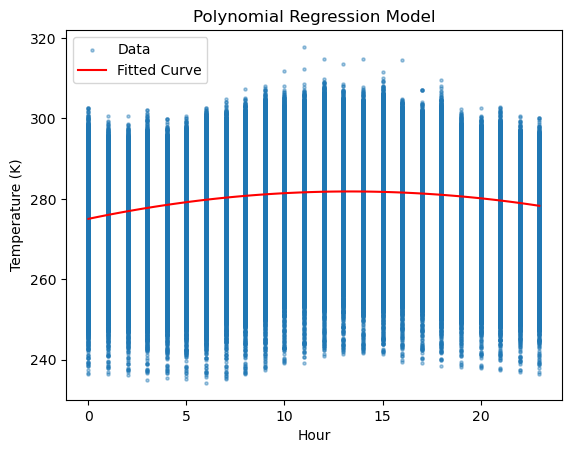

In [61]:
#Generate smooth x values
x_smooth = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_smooth_poly = transformer.transform(x_smooth)

y_pred = model.predict(x_smooth_poly)

plt.scatter(x, y, label='Data', s = 5, alpha = 0.4)
plt.plot(x_smooth, y_pred, color='red', label='Fitted Curve')
plt.legend()
plt.xlabel("Hour")
plt.ylabel("Temperature (K)")
plt.title("Polynomial Regression Model")
plt.show()


### A trial with Taiwan  for time conversion to local time

In [63]:
#obs_india = obs[(obs['latitude']>7.97) & (obs['latitude'] < 35.50) & (obs['longitude']>68.18) & (obs['longitude'] < 97.41)].copy()
obs_thai = obs[(obs['latitude']>21.97) & (obs['latitude'] < 25.30) & (obs['longitude']>120) & (obs['longitude'] < 122)]
obs_thai

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celsius
2352385,290.7,2025-02-01 00:00:00+00:00,58968,temperature_at_screen_level,25.033,121.517,9.0,1.000000,2.404660,32,0,0.52342,0.85208,0.85249,-0.52275,0.27814,0.85249,-0.52275,17.7
2352386,295.6,2025-02-01 03:00:00+00:00,58968,temperature_at_screen_level,25.033,121.517,9.0,1.000000,2.404660,32,3,0.52342,0.85208,0.23316,-0.97244,0.27814,0.85249,-0.52275,22.6
2352389,293.2,2025-02-01 00:00:00+00:00,59358,temperature_at_screen_level,23.000,120.217,14.0,0.889210,0.115792,32,0,0.52342,0.85208,0.86413,-0.50328,0.25556,0.86413,-0.50328,20.2
2352390,298.2,2025-02-01 03:00:00+00:00,59358,temperature_at_screen_level,23.000,120.217,14.0,0.889210,0.115792,32,3,0.52342,0.85208,0.25516,-0.96690,0.25556,0.86413,-0.50328,25.2
2352391,292.1,2025-02-01 00:00:00+00:00,59562,temperature_at_screen_level,22.750,121.150,10.0,0.666434,0.030000,32,0,0.52342,0.85208,0.85582,-0.51728,0.25278,0.85582,-0.51728,19.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619259,299.1,2025-05-19 18:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,139,18,0.68077,-0.73249,0.52324,0.85218,0.24481,0.85218,-0.52324,26.1
2619260,299.0,2025-05-19 21:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,139,21,0.68077,-0.73249,0.97257,0.23260,0.24481,0.85218,-0.52324,26.0
2619364,301.3,2025-05-20 03:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,140,3,0.66806,-0.74410,0.23260,-0.97257,0.24481,0.85218,-0.52324,28.3
2619459,300.3,2025-05-20 06:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,140,6,0.66806,-0.74410,-0.52324,-0.85218,0.24481,0.85218,-0.52324,27.3


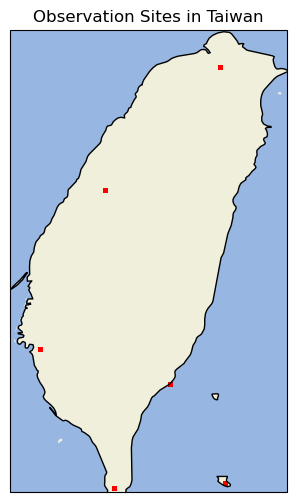

In [64]:
# Create a map of Taiwan
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([120, 122, 21.97, 25.3], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(obs_thai['longitude'], obs_thai['latitude'], color='red', s=5, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Observation Sites in Taiwan")
plt.show()

Text(0.5, 1.0, 'temp vs hour to find the hour with peak temperature')

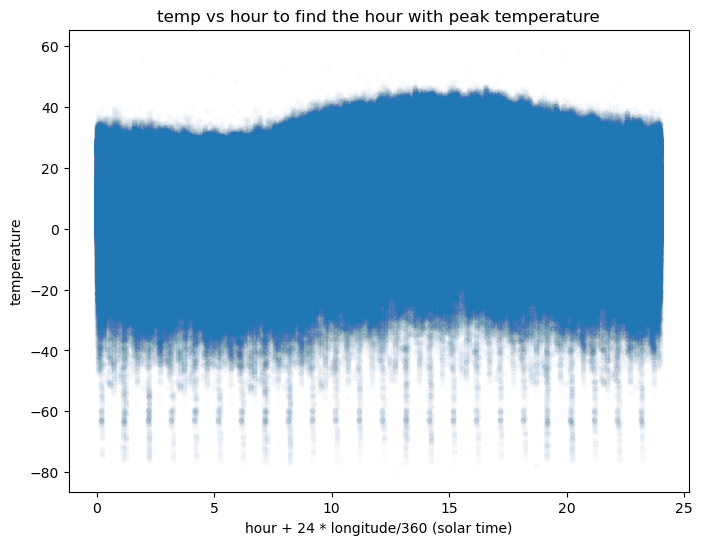

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(np.fmod(obs['hour'] + 24 * (obs['longitude'] / 360)+24,24), obs['temp_celsius'], alpha=0.01, s=10)
#plt.plot((obs_thai['hour'] + 24 * (obs_thai['longitude'] / 360)))
#obs['hour'] + 24 * (obs['longitude'] / 360)
#plt.scatter(obs_thai[(obs_thai['day_of_year'] > 80) & (obs_thai['day_of_year'] < 100)]['hour'], obs_thai[(obs_thai['day_of_year'] > 80) & (obs_thai['day_of_year'] < 100)]['temp_celsius'], alpha=0.5, s=10)
plt.xlabel('hour + 24 * longitude/360 (solar time)')
plt.ylabel('temperature')
plt.title('temp vs hour to find the hour with peak temperature')


In [66]:
np.max(obs_thai['longitude'])

121.55

Text(0.5, 1.0, 'temp vs hour to find the hour with peak temperature')

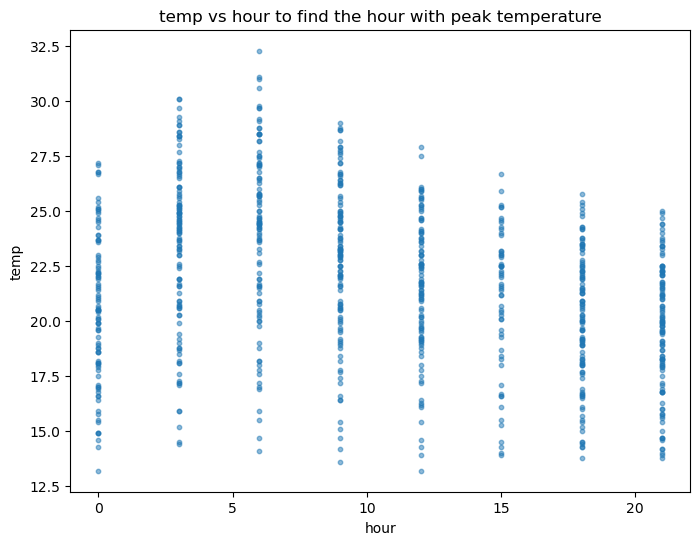

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(obs_thai[(obs_thai['day_of_year'] > 80) & (obs_thai['day_of_year'] < 100)]['hour'], obs_thai[(obs_thai['day_of_year'] > 80) & (obs_thai['day_of_year'] < 100)]['temp_celsius'], alpha=0.5, s=10)
plt.xlabel('hour')
plt.ylabel('temp')
plt.title('temp vs hour to find the hour with peak temperature')


This tells us that the time is not local time but UTC +0.00 time (UK time) for all observations. It is important to convert the time to local time at each location, otherwise the temperature variation with hour of the day will not be captured appropriately.
The peak at hour 6 clearly explains the time offset of 8 hours between UK and Taiwan.

#### UTC time to local time

We'll use the TimezoneFinder package to convert the time to local time based on latitudes and longitudes.

Reference: https://measurespace.medium.com/test-83e52da869c8

In [71]:
from timezonefinder import TimezoneFinder

In [72]:
obs_thai.iloc[4]['longitude'] 

121.15

In [73]:
# Find timezone based on longitude and latitude
tf = TimezoneFinder(in_memory=True)

def get_timezone(row):
    return tf.timezone_at(lng=row['longitude'], lat=row['latitude'])

obs_thai.loc[:,'local_time_zone'] = obs_thai.apply(get_timezone, axis=1)

#for i in enumerate(obs_thai):
 #   obs_thai.iloc[i]['local_time_zone'] = tf.timezone_at(lng=obs_thai.iloc[i]['longitude'], lat=obs_thai.iloc[i]['latitude'])
#local_time_zone

/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_12501/850852736.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_thai.loc[:,'local_time_zone'] = obs_thai.apply(get_timezone, axis=1)


In [74]:
obs_thai['local_time_zone']

2352385    Asia/Taipei
2352386    Asia/Taipei
2352389    Asia/Taipei
2352390    Asia/Taipei
2352391    Asia/Taipei
              ...     
2619259    Asia/Taipei
2619260    Asia/Taipei
2619364    Asia/Taipei
2619459    Asia/Taipei
2619460    Asia/Taipei
Name: local_time_zone, Length: 4709, dtype: object

In [75]:
# Convert UTC to local time

def set_timezone(row):
    return row['time'].tz_convert(row['local_time_zone'])

obs_thai.loc[:,'local_time'] = obs_thai.apply(set_timezone, axis=1)
#test_local = test_UTC.tz_convert(local_time_zone)
obs_thai['local_time']


/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_12501/2167412079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_thai.loc[:,'local_time'] = obs_thai.apply(set_timezone, axis=1)


2352385   2025-02-01 08:00:00+08:00
2352386   2025-02-01 11:00:00+08:00
2352389   2025-02-01 08:00:00+08:00
2352390   2025-02-01 11:00:00+08:00
2352391   2025-02-01 08:00:00+08:00
                     ...           
2619259   2025-05-20 02:00:00+08:00
2619260   2025-05-20 05:00:00+08:00
2619364   2025-05-20 11:00:00+08:00
2619459   2025-05-20 14:00:00+08:00
2619460   2025-05-20 17:00:00+08:00
Name: local_time, Length: 4709, dtype: datetime64[ns, Asia/Taipei]

In [76]:
obs_thai

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,...,sin_day,cos_day,sin_hour,cos_hour,lat,sin_long,cos_long,temp_celsius,local_time_zone,local_time
2352385,290.7,2025-02-01 00:00:00+00:00,58968,temperature_at_screen_level,25.033,121.517,9.0,1.000000,2.404660,32,...,0.52342,0.85208,0.85249,-0.52275,0.27814,0.85249,-0.52275,17.7,Asia/Taipei,2025-02-01 08:00:00+08:00
2352386,295.6,2025-02-01 03:00:00+00:00,58968,temperature_at_screen_level,25.033,121.517,9.0,1.000000,2.404660,32,...,0.52342,0.85208,0.23316,-0.97244,0.27814,0.85249,-0.52275,22.6,Asia/Taipei,2025-02-01 11:00:00+08:00
2352389,293.2,2025-02-01 00:00:00+00:00,59358,temperature_at_screen_level,23.000,120.217,14.0,0.889210,0.115792,32,...,0.52342,0.85208,0.86413,-0.50328,0.25556,0.86413,-0.50328,20.2,Asia/Taipei,2025-02-01 08:00:00+08:00
2352390,298.2,2025-02-01 03:00:00+00:00,59358,temperature_at_screen_level,23.000,120.217,14.0,0.889210,0.115792,32,...,0.52342,0.85208,0.25516,-0.96690,0.25556,0.86413,-0.50328,25.2,Asia/Taipei,2025-02-01 11:00:00+08:00
2352391,292.1,2025-02-01 00:00:00+00:00,59562,temperature_at_screen_level,22.750,121.150,10.0,0.666434,0.030000,32,...,0.52342,0.85208,0.85582,-0.51728,0.25278,0.85582,-0.51728,19.1,Asia/Taipei,2025-02-01 08:00:00+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619259,299.1,2025-05-19 18:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,139,...,0.68077,-0.73249,0.52324,0.85218,0.24481,0.85218,-0.52324,26.1,Asia/Taipei,2025-05-20 02:00:00+08:00
2619260,299.0,2025-05-19 21:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,139,...,0.68077,-0.73249,0.97257,0.23260,0.24481,0.85218,-0.52324,26.0,Asia/Taipei,2025-05-20 05:00:00+08:00
2619364,301.3,2025-05-20 03:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,140,...,0.66806,-0.74410,0.23260,-0.97257,0.24481,0.85218,-0.52324,28.3,Asia/Taipei,2025-05-20 11:00:00+08:00
2619459,300.3,2025-05-20 06:00:00+00:00,59567,temperature_at_screen_level,22.033,121.550,325.0,0.000000,0.030000,140,...,0.66806,-0.74410,-0.52324,-0.85218,0.24481,0.85218,-0.52324,27.3,Asia/Taipei,2025-05-20 14:00:00+08:00


### Visualising sites which have extreme temperatures

In [78]:
cold_sites = obs[(obs['temp_celsius'] < -60.0)]
cold_sites.shape

(2143, 19)

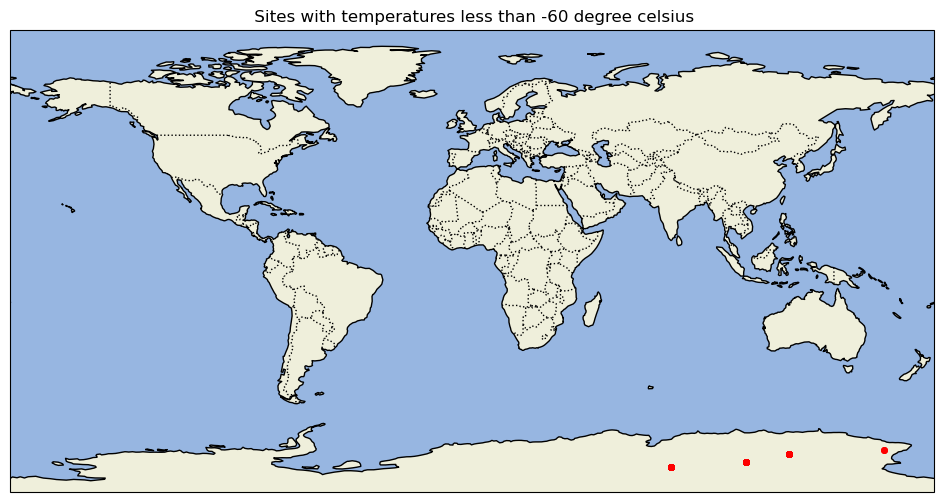

In [79]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([120, 122, 21.97, 25.3], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(cold_sites['longitude'], cold_sites['latitude'], color='red', s=15, alpha=0.7, transform=ccrs.PlateCarree())

plt.title(" Sites with temperatures less than -60 degree celsius")
plt.show()

In [80]:
warm_sites = obs[(obs['temp_celsius'] > 60.0)]
warm_sites.shape

(0, 19)

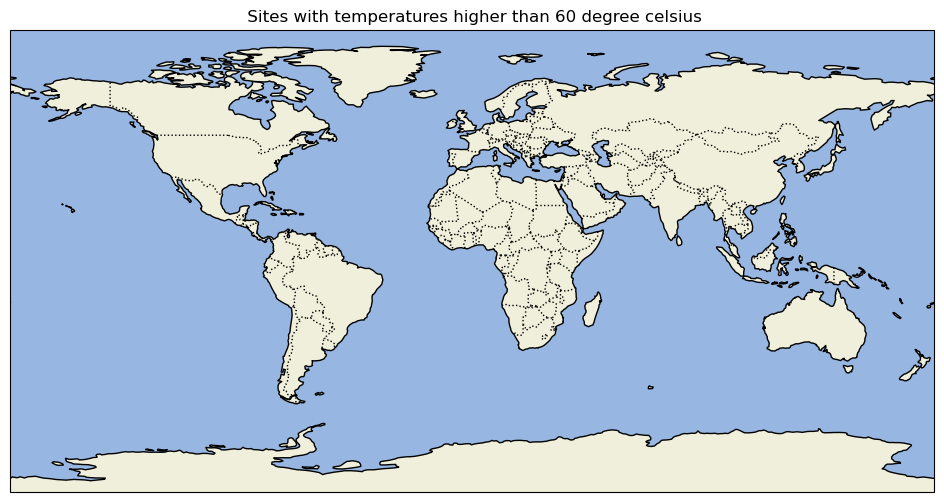

In [81]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([120, 122, 21.97, 25.3], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
ax.scatter(warm_sites['longitude'], warm_sites['latitude'], color='red', s=15, alpha=0.7, transform=ccrs.PlateCarree())

plt.title(" Sites with temperatures higher than 60 degree celsius")
plt.show()

### Conclusion

This notebook mainly dealt with analysis of the dataset and study of its characteristics. We learnt variations of temperature and it is affected by static variables such as altitude and time.